# Capstone Assignment 20.1: Initial Report and Exploratory Data Analysis

**Overview**: This notebook provides exploratory data analysis and a baseline model on the [Real / Fake Job Posting Prediction Dataset](https://www.kaggle.com/datasets/shivamb/real-or-fake-fake-jobposting-prediction), making use of the article accompanying the dataset [here](https://www.icsd.aegean.gr/publication_files/290421648.pdf)



### Section 1: Understanding the Data

Before modeling, we confirm:
- the prediction target (binary classification),
- feature types (numeric vs categorical),
- missing values
- class imbalance 

### Section 2: Reading the Data

Use pandas to read in the dataset `fake_job_postings.csv` and assign to a meaningful variable name.

In [ ]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

import re
import time

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.inspection import permutation_importance
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE

from wordcloud import WordCloud

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)

In [2]:
job_postings = pd.read_csv('data/fake_job_postings.csv')
print("Shape:", job_postings.shape)

Shape: (17880, 18)


In [30]:
job_postings.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,...,fraudulent,description_len,description_wc,company_profile_len,company_profile_wc,requirements_len,requirements_wc,benefits_len,benefits_wc,text
0,1,Marketing Intern,"US, NY, New York",Marketing,unknown,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,...,0,905.0,124.0,885.0,141.0,852.0,115.0,NaN,NaN,"Food52, a fast-growing, James Beard Award-winn..."
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,unknown,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,...,0,2077.0,315.0,1286.0,153.0,1433.0,200.0,1292.0,227.0,Organised - Focused - Vibrant - Awesome!Do you...
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",unknown,unknown,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,...,0,355.0,50.0,879.0,141.0,1363.0,164.0,NaN,NaN,"Our client, located in Houston, is actively se..."
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,unknown,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,...,0,2600.0,346.0,614.0,85.0,1429.0,176.0,782.0,97.0,THE COMPANY: ESRI – Environmental Systems Rese...
4,5,Bill Review Manager,"US, FL, Fort Worth",unknown,unknown,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,...,0,1520.0,168.0,1628.0,207.0,757.0,89.0,21.0,3.0,JOB TITLE: Itemization Review ManagerLOCATION:...


In [4]:
job_postings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

### Observations

Given the column info and head samples, we can deduce the following:
- job_id is a unique ID which likely has little correlation to fraudulence
- salary range likely correlates to region/country. An unrealistic range -- too wide, or atypical to the job title - could correlate to fraudulency

### Section 3: Understanding the Features

Here, we examine the data, evaluating missingness, categorical vs text features.

In [51]:
job_postings.describe()

,job_id,telecommuting,has_company_logo,has_questions,fraudulent,description_len,description_wc,company_profile_len,company_profile_wc,requirements_len,requirements_wc,benefits_len,benefits_wc
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000,17879.000000,17879.000000,14572.000000,14572.000000,15184.000000,15184.000000,10668.000000,10668.000000
mean,8940.500000,0.042897,0.795302,0.491723,0.048434,1218.057889,170.447005,761.851702,113.563203,694.907337,91.883759,350.114548,50.265279
std,5161.655742,0.202631,0.403492,0.499945,0.214688,894.785353,123.288060,536.392490,81.123935,608.230393,81.100178,375.487975,55.947455
min,1.000000,0.000000,0.000000,0.000000,0.000000,6.000000,0.000000,9.000000,1.000000,1.000000,0.000000,1.000000,0.000000
25%,4470.750000,0.000000,1.000000,0.000000,0.000000,607.000000,87.000000,392.000000,56.000000,301.000000,39.000000,91.000000,11.000000
50%,8940.500000,0.000000,1.000000,0.000000,0.000000,1017.000000,146.000000,684.000000,97.000000,562.000000,74.000000,237.000000,33.000000
75%,13410.250000,0.000000,1.000000,1.000000,0.000000,1586.000000,224.000000,1022.000000,148.000000,904.000000,119.250000,488.000000,72.000000
max,17880.000000,1.000000,1.000000,1.000000,1.000000,14907.000000,2115.000000,6178.000000,885.000000,10864.000000,1645.000000,4429.000000,694.000000


In [6]:
def data_quality_report(df):
  return pd.DataFrame({
    'data_type': df.dtypes,
    'non_null_count': df.notnull().sum(),
    'null_count': df.isnull().sum(),
    'na_count': df.isna().sum(),
    'na_percentage': (df.isna().sum() / len(df)) * 100,
    'null_percentage': (df.isnull().sum() / len(df)) * 100,
    'unique_values': df.nunique(),
    'sample_value': df.dropna().sample().iloc[0]
  })


In [7]:
data_quality_report(job_postings)

,data_type,non_null_count,null_count,na_count,na_percentage,null_percentage,unique_values,sample_value
job_id,int64,17880,0,0,0.000000,0.000000,17880,6781
title,object,17880,0,0,0.000000,0.000000,11231,Application Developer C#.NET
location,object,17534,346,346,1.935123,1.935123,3105,"PH, 00, makati"
department,object,6333,11547,11547,64.580537,64.580537,1337,Information Technology
salary_range,object,2868,15012,15012,83.959732,83.959732,874,15000-30000
company_profile,object,14572,3308,3308,18.501119,18.501119,1709,"Collabera is a fast growing, end-to-end inform..."
description,object,17879,1,1,0.005593,0.005593,14801,Job Title :- Application Developer C#.NETLocat...
requirements,object,15184,2696,2696,15.078300,15.078300,11967,Programming Languages.• Apply Knowledge of Bus...
benefits,object,10668,7212,7212,40.335570,40.335570,6204,"Collabera is a fast growing, end-to-end inform..."
telecommuting,int64,17880,0,0,0.000000,0.000000,2,0


### Section 4: Most Missing Columns

Fraudulent postings often have more missing fields, e.g. no company logo, salary range, company profile.

/var/folders/zq/7j33ffkd46vd0yzyrk5qyj140000gn/T/ipykernel_16116/942558542.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_class = job_postings.groupby('fraudulent').apply(


fraudulent                  0         1
salary_range         0.844540  0.742494
company_profile      0.159927  0.677829
department           0.647467  0.613164
required_education   0.449865  0.520785
required_experience  0.388797  0.502309
benefits             0.402492  0.420323
function             0.359586  0.389145
industry             0.272011  0.317552
employment_type      0.189844  0.278291
requirements         0.149406  0.177829
location             0.019219  0.021940
description          0.000000  0.001155
job_id               0.000000  0.000000
telecommuting        0.000000  0.000000
has_questions        0.000000  0.000000
has_company_logo     0.000000  0.000000
title                0.000000  0.000000
fraudulent           0.000000  0.000000


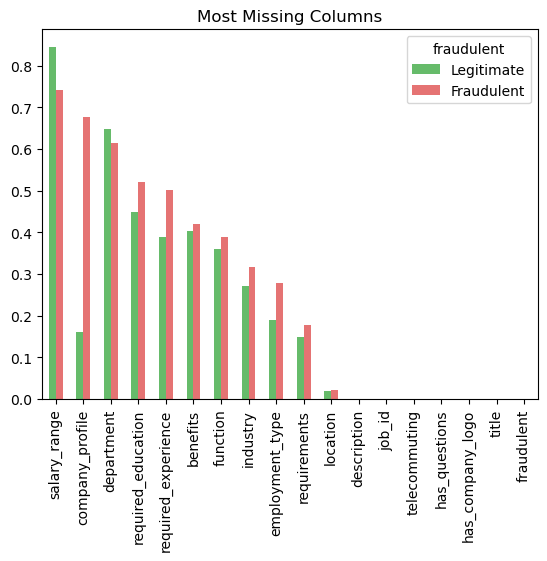

In [8]:
missing_by_class = job_postings.groupby('fraudulent').apply(
    lambda x: x.isnull().mean()
).T.sort_values(by=1, ascending=False)
print(missing_by_class)

##     ct.plot(kind='bar', color=['#E57373', '#66BB6A'], width=0.8, ax=axes[idx])
missing_plot = missing_by_class.plot(kind='bar', color=['#66BB6A', '#E57373'], legend=['Legitimate', 'Fraudulent'], title="Most Missing Columns")
legend = missing_plot.get_legend()

for text, label in zip(legend.get_texts(), ['Legitimate', 'Fraudulent']):
    text.set_text(label)

## Observations

Here, we can see that salary range has the most missing data, with company_profile, department, required_education closely trailing behind.

Here,  lack of a company profile could be a strong indicator of fraudulency.

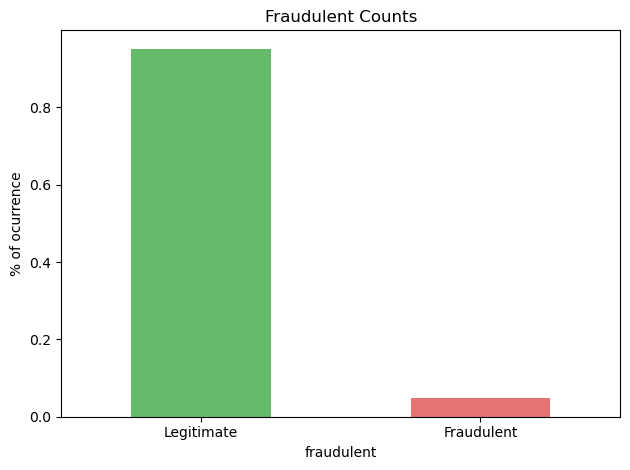

In [9]:
fraudulent_counts = job_postings['fraudulent'].value_counts(normalize=True)

fraudulent_counts.plot(title="Fraudulent Counts", kind="bar", color=['#66BB6A', '#E57373'])
plt.ylabel("% of ocurrence")
plt.xticks([0, 1], ["Legitimate", "Fraudulent"])
plt.tick_params(axis='x', rotation=0)
plt.savefig('images/fraudulent_counts.png')
plt.tight_layout()

### Section 5: Understanding the Task

**Business objective:** predict which job postings are fraudulent vs legitimate, so applicants can avoid providing PPI to scammers.

**ML objective:** learn a mapping from customer features to a binary response label and evaluate competing classifiers using cross-valdiation and a held-out test set.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

### Section 6: Understanding and Visualizing Features

The following columns:
- description
- company_profile
- requirements
- benefits

are text columns suited for NLP feature engineering.

In [104]:
text_columns = ['description', 'company_profile', 'requirements', 'benefits'] 

In [105]:
num_cols = job_postings.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [col for col in job_postings.select_dtypes(include='object').columns.tolist() if col not in text_columns]

print("Numeric features:", num_cols)
print("Categorical features:", cat_cols)

Numeric features: ['job_id', 'telecommuting', 'has_company_logo', 'has_questions', 'fraudulent', 'description_len', 'description_wc', 'company_profile_len', 'company_profile_wc', 'requirements_len', 'requirements_wc', 'benefits_len', 'benefits_wc']
Categorical features: ['title', 'location', 'department', 'salary_range', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'text']


In [106]:
for col in cat_cols + text_columns:
    job_postings[col] = job_postings[col].fillna("unknown")

### Understanding Numerical Correlations

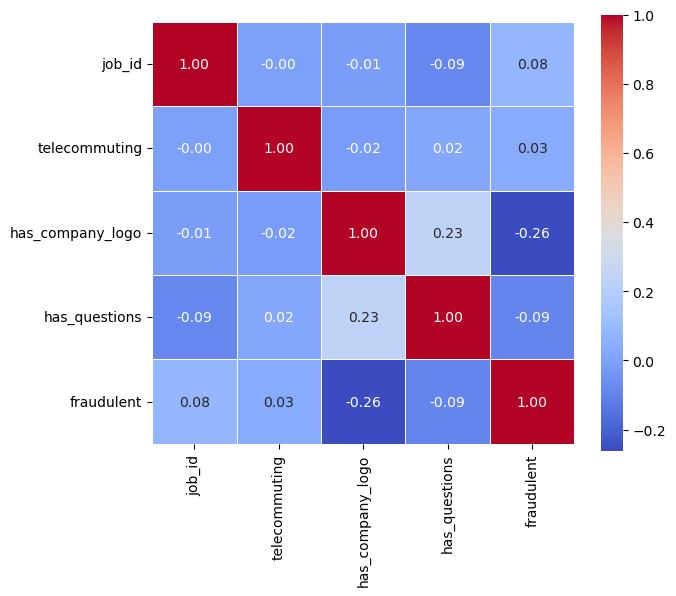

In [56]:
corr_matrix = job_postings[num_cols].corr()
n = len(corr_matrix.columns)

fig, ax = plt.subplots(figsize=(n * 1.4, n * 1.2))

sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt='.2f', linewidth=0.4, linecolor='white', square=True)
plt.savefig('images/numerical_correlations_heatmap.png')
plt.tight_layout()

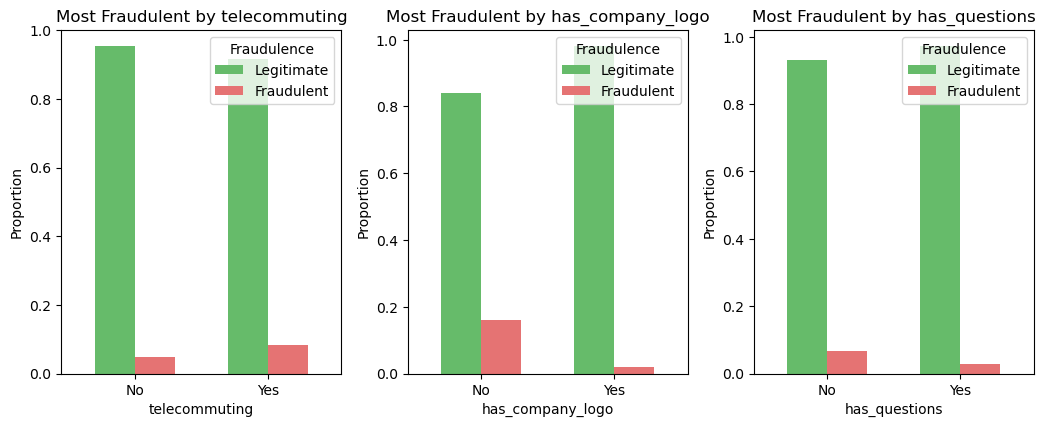

In [57]:
num_to_plot = [c for c in num_cols if c not in ['job_id', 'fraudulent'] and not bool(re.search(r'_len', col))]

# Calculate rows and columns for better layout
n_plots = len(num_to_plot)
n_cols = 4  # or however many columns you want
n_rows = 4

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))

# This safely handles 1x1, 1D, and 2D arrays identically
axes = np.array(axes).flatten()

# Plot each distribution
for idx, col in enumerate(num_to_plot):
   
    ct = pd.crosstab(job_postings[col], job_postings['fraudulent'], normalize='index')
    
    # Stacked bar chart
    ct.plot(kind='bar', 
            ax=axes[idx], 
            color=['#66BB6A', '#E57373'],
            width=0.6)
    
    axes[idx].set_title(f"Most Fraudulent by {col}")
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel("Proportion")
    
    if job_postings[col].nunique() == 2:
        axes[idx].set_xticklabels(['No', 'Yes'], rotation=0)
    axes[idx].legend(['Legitimate', 'Fraudulent'], title='Fraudulence')

# Hide unused subplots
for idx in range(n_plots, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig('images/numerical_bar_plots.png')
plt.show()

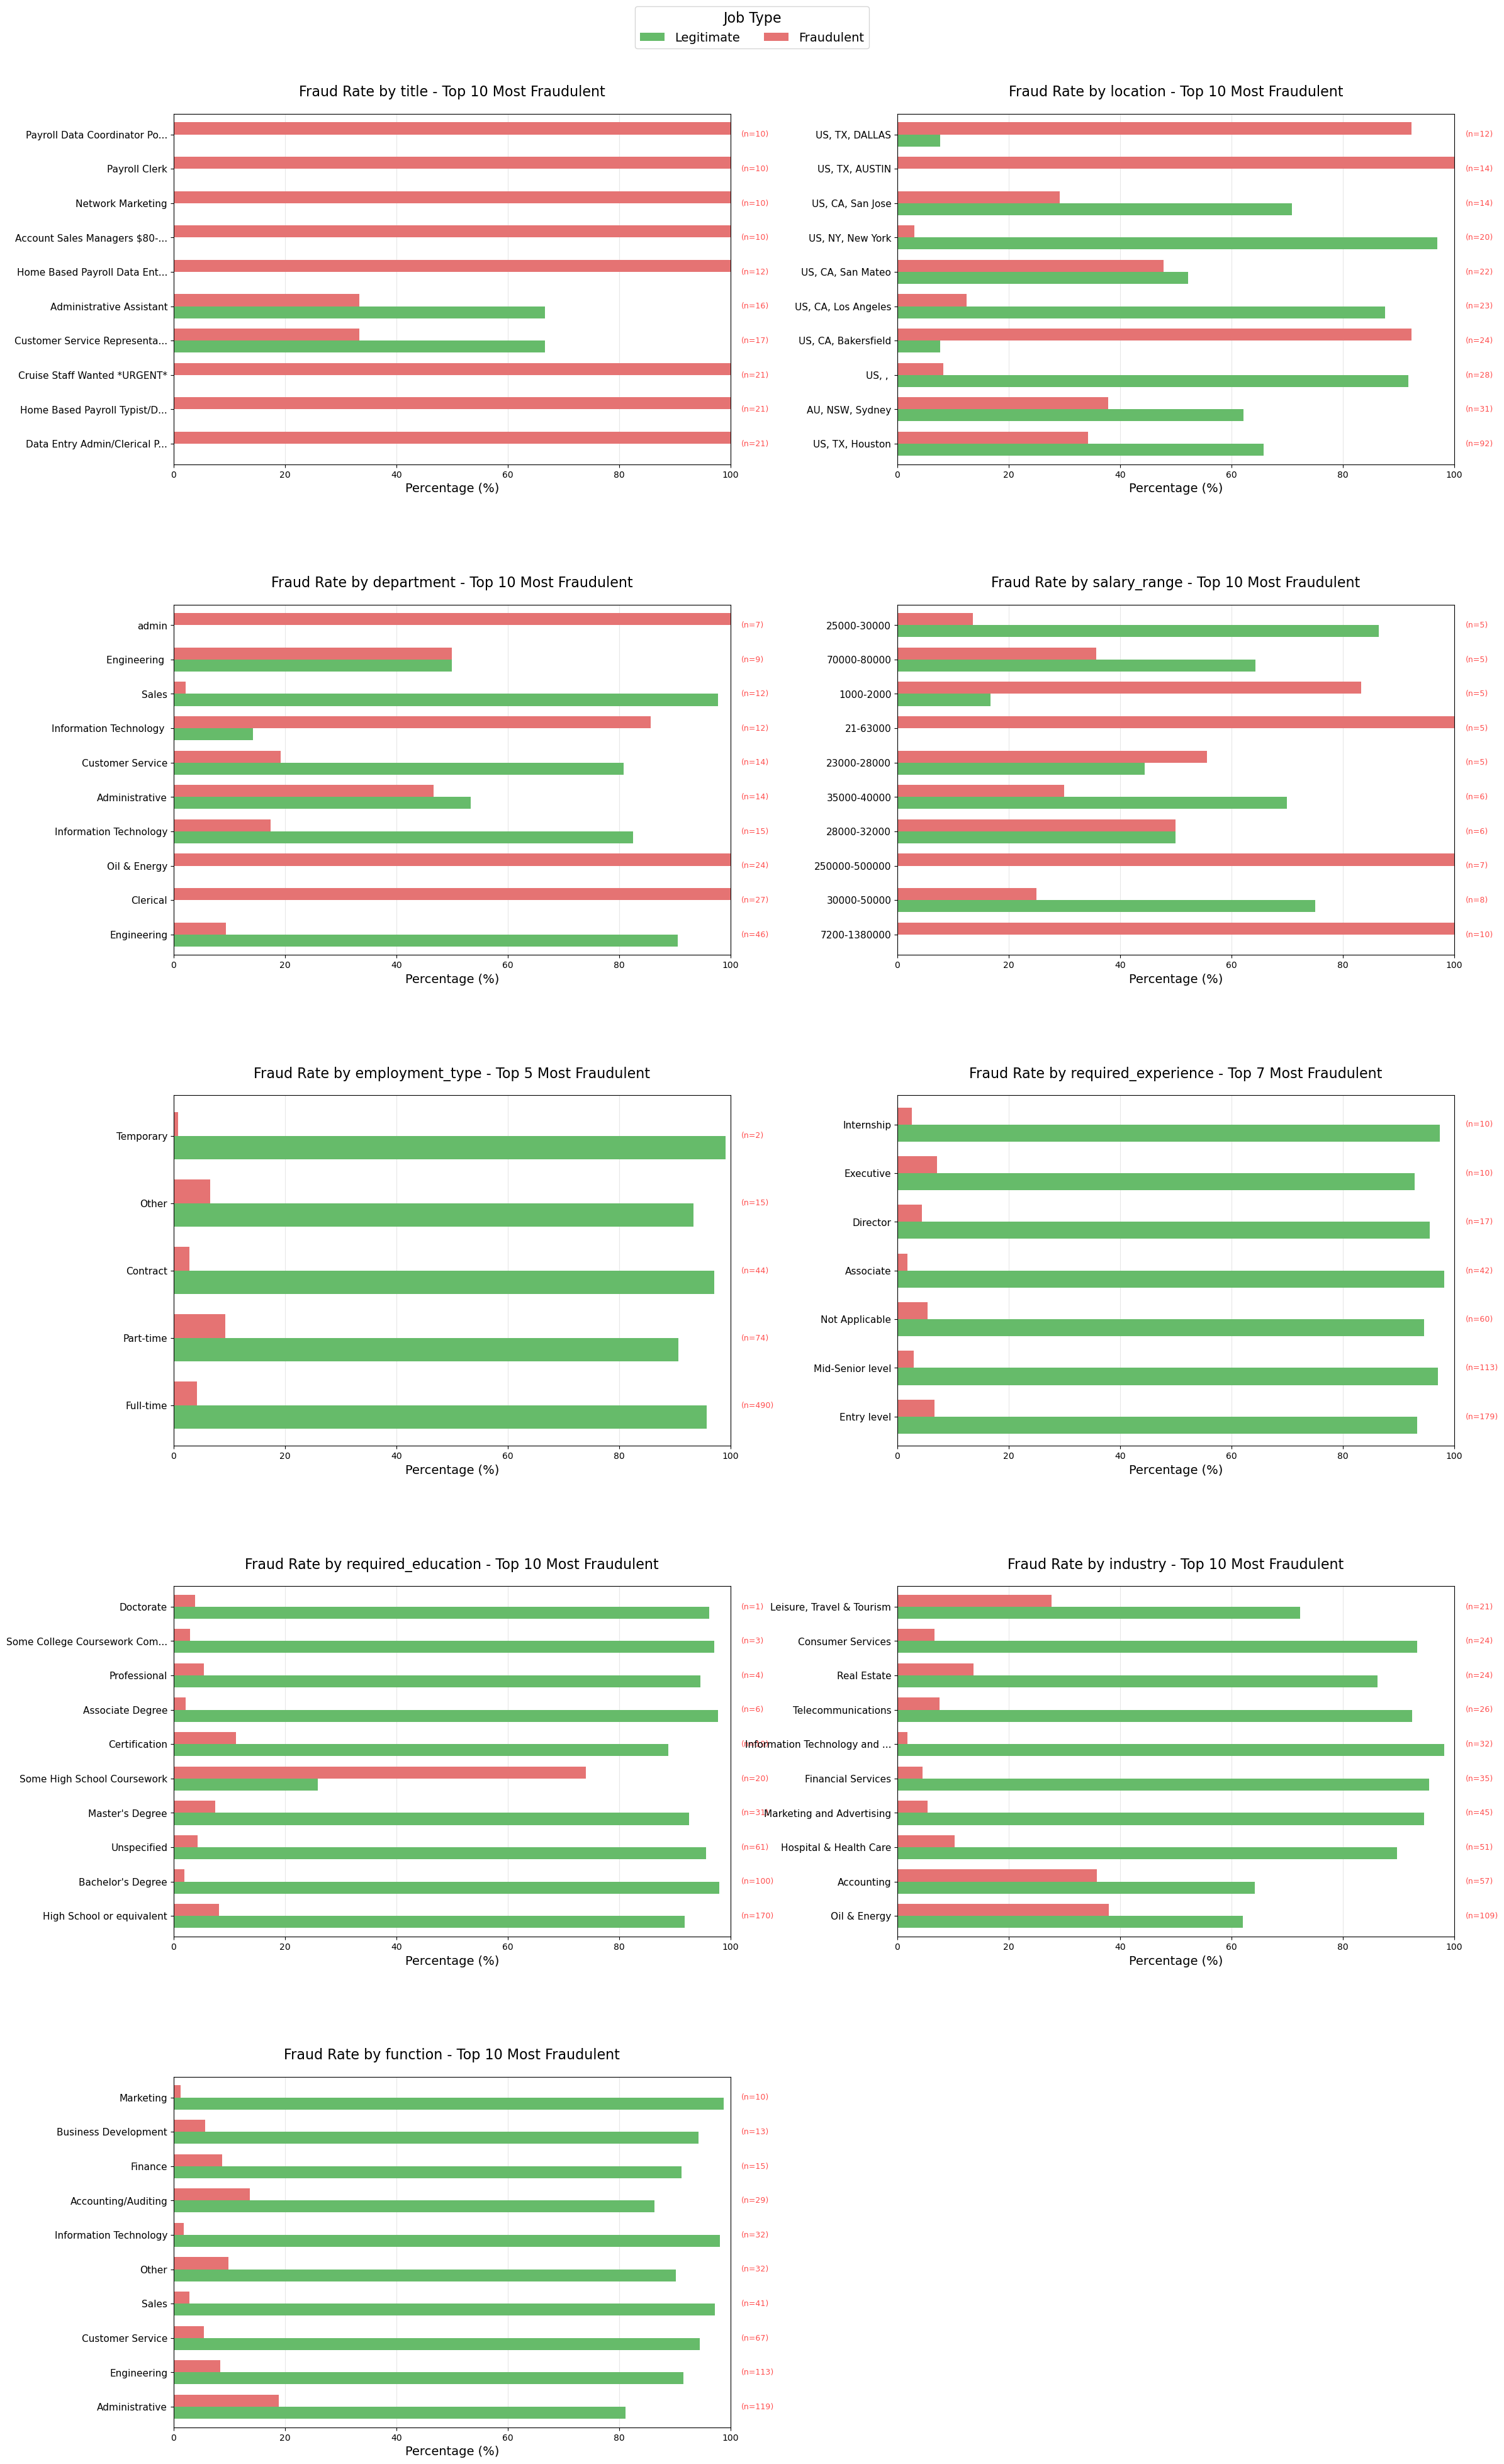

In [ ]:
cat_to_plot = [c for c in cat_cols if c not in ['fraudulent'] + text_columns]

# Calculate rows and columns for better layout
n_plots = len(cat_to_plot)
n_cols = 2
n_rows = (n_plots + n_cols - 1) // n_cols

# Create figure with even larger size for horizontal bars
fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 8 * n_rows))
axes = axes.flatten() if n_plots > 1 else [axes]

# Plot each categorical variable
for idx, col in enumerate(cat_to_plot):
    # Get categories with highest fraud counts (fraudulent == 1)
    fraud_counts = job_postings[job_postings['fraudulent'] == 1][col].value_counts().head(10)
    top_fraud_categories = fraud_counts.index
    
    # Filter data to only include top fraudulent categories
    filtered_data = job_postings[job_postings[col].isin(top_fraud_categories)]
    
    # Create crosstab with percentages for filtered data
    ct = pd.crosstab(filtered_data[col], filtered_data['fraudulent'], normalize='index') * 100
    
    # Reorder by fraud count (most fraudulent first)
    ct = ct.reindex(top_fraud_categories)
    
    # Create horizontal bar plot
    ct.plot(kind='barh', 
            color=['#66BB6A', '#E57373'],
            width=0.7, 
            ax=axes[idx])
    
    # Set title and labels
    axes[idx].set_title(f"Fraud Rate by {col} - Top {len(top_fraud_categories)} Most Fraudulent", fontsize=16, pad=20)
    axes[idx].set_xlabel("Percentage (%)", fontsize=14)
    axes[idx].set_ylabel("", fontsize=12)
    
    # Remove individual legends
    if axes[idx].get_legend():
        axes[idx].get_legend().remove()
    
    labels = axes[idx].get_yticklabels()
    processed_labels = []
    for label in labels:
        text = label.get_text()
        
        # Then truncate if still too long
        if len(text) > 30:
            text = text[:27] + "..."
        
        processed_labels.append(text)
    
    axes[idx].set_yticklabels(processed_labels, fontsize=11)
    
    # Set x-axis limits for consistency
    axes[idx].set_xlim(0, 100)
    
    # Add grid for better readability
    axes[idx].grid(axis='x', alpha=0.3)
    axes[idx].set_axisbelow(True)
    
    # Add fraud count annotation to the right of each bar
    for i, (category, count) in enumerate(fraud_counts.items()):
        axes[idx].text(102, i, f'(n={count})', 
                      va='center', fontsize=9, color='red', alpha=0.7)

# Hide unused subplots
for idx in range(len(cat_to_plot), len(axes)):
    axes[idx].set_visible(False)

# Add a single shared legend at the top of the figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, 
    ['Legitimate', 'Fraudulent'], 
           title='Job Type',
           loc='upper center', 
           bbox_to_anchor=(0.5, 0.98),
           ncol=2, 
           fontsize=14,
           title_fontsize=16)

# Adjust layout with more spacing
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.savefig('images/top_fraudulent_categories.png')
plt.show()

### Feature Extraction

Since the text and word lengths can differ between legitimate and fraudulent job postings, extract these lengths into numerical features.

In [58]:
def extract_features(df):
  for c in text_columns:
    df[c + "_len"] = df[c].str.len()
    df[c + "_wc"] = df[c].str.split().str.len()

extract_features(job_postings)

### Text Fields

For text fields, we can see what type of words are frequent in fraudulent and legitimate jobs using wordclouds.

In the below code block, text fields are combined into one single column 

In [107]:
job_postings['text'] = job_postings[text_columns].fillna('').agg(
    lambda x: ' | '.join(filter(None, x)), axis=1
)

job_postings_clean = job_postings.drop(columns=text_columns)

job_postings_clean.shape

(17880, 23)

In [108]:
fraudulent_text = job_postings_clean[job_postings_clean['fraudulent'] == 1]['text']
legitimate_text = job_postings_clean[job_postings_clean['fraudulent'] == 0]['text']

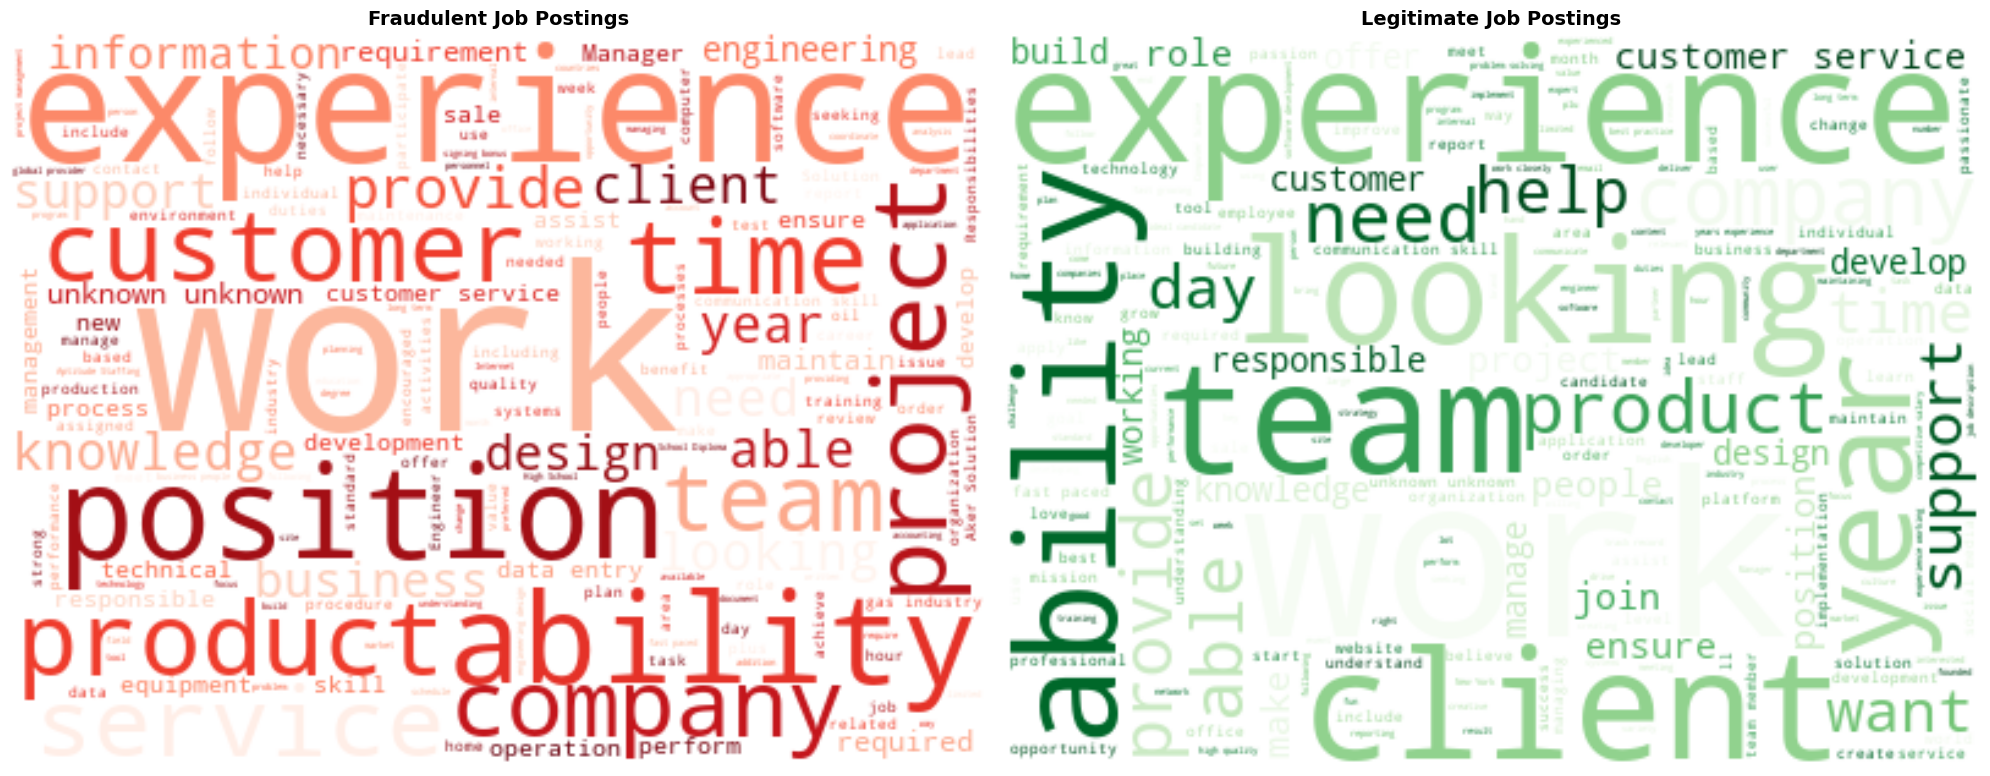

In [109]:
from sklearn.feature_extraction import text
STOP_WORDS = text.ENGLISH_STOP_WORDS

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Fraudulent wordcloud
fraudulent_wc = WordCloud(
    stopwords=STOP_WORDS, width=400, height=300, 
    background_color='white', colormap='Reds'
).generate(' '.join(fraudulent_text))

ax1.imshow(fraudulent_wc, interpolation='bilinear')
ax1.set_title('Fraudulent Job Postings', fontsize=14, fontweight='bold')
ax1.axis('off')

# Legitimate wordcloud  
legitimate_text = job_postings[job_postings['fraudulent'] == 0]['text'].dropna()
legitimate_wc = WordCloud(
    stopwords=STOP_WORDS, width=400, height=300,
    background_color='white', colormap='Greens'
).generate(' '.join(legitimate_text))

ax2.imshow(legitimate_wc, interpolation='bilinear')
ax2.set_title('Legitimate Job Postings', fontsize=14, fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.show()


### Section 7: Anomaly & Outlier Detection

As the rubric includes a section for analyzing outliers and anomalies, we analyze any outliers within salary range, which is 83% null.

In [ ]:
def parse_salary_range(salary_str):
    """Parse salary range string and return min, max, and validity flag"""
    if pd.isna(salary_str) or salary_str == 'nan':
        return np.nan, np.nan, 'missing'
    
    # Remove commas and spaces
    salary_str = str(salary_str).replace(',', '').replace(' ', '')
    
    # Check for obvious errors
    if salary_str == '0-0':
        return 0, 0, 'zero_range'
    
    # Date-like patterns (e.g., '9-Dec', 'Oct-15', 'Jun-18')
    if re.match(r'^\w+-\w+$', salary_str) and any(month in salary_str for month in ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']):
        return np.nan, np.nan, 'date_error'
    
    # Single value (e.g., '40000')
    if '-' not in salary_str:
        try:
            val = float(salary_str)
            return val, val, 'single_value'
        except:
            return np.nan, np.nan, 'parse_error'
    
    # Range values
    try:
        parts = salary_str.split('-')
        if len(parts) == 2:
            min_sal = float(parts[0])
            max_sal = float(parts[1])
            
            # Check for reversed ranges
            if min_sal > max_sal:
                return max_sal, min_sal, 'reversed_range'
            
            # Check for unrealistic ranges
            if max_sal > 1e9:  # More than 1 billion
                return min_sal, max_sal, 'unrealistic_high'
            
            if max_sal < 100 and max_sal > 0:  # Likely hourly rate
                return min_sal, max_sal, 'likely_hourly'
            
            return min_sal, max_sal, 'valid'
        else:
            return np.nan, np.nan, 'parse_error'
    except:
        return np.nan, np.nan, 'parse_error'

# Apply parsing
job_postings_clean['salary_min'], job_postings_clean['salary_max'], job_postings_clean['salary_status'] = zip(*job_postings_clean['salary_range'].apply(parse_salary_range))
job_postings_clean['salary_mid'] = (job_postings_clean['salary_min'] + job_postings_clean['salary_max']) / 2
job_postings_clean['salary_spread'] = job_postings_clean['salary_max'] - job_postings_clean['salary_min']

job_postings_clean[['salary_min', 'salary_mid', 'salary_spread']].dropna()

,salary_min,salary_mid,salary_spread
6,20000.0,24000.0,8000.0
10,100000.0,110000.0,20000.0
15,120000.0,135000.0,30000.0
23,100000.0,110000.0,20000.0
31,50000.0,57500.0,15000.0
...,...,...,...
17844,0.0,0.0,0.0
17849,80000.0,90000.0,20000.0
17865,18000.0,19000.0,2000.0
17867,18000.0,18500.0,1000.0


In [ ]:
def extract_country_from_location(location):
    """Extract country from location string"""
    if pd.isna(location):
        return 'Unknown'
    
    # Common patterns
    location = str(location).strip()
    
    # Check for country codes or full country names at the end
    parts = location.split(',')
    if len(parts) > 0:
        last_part = parts[-1].strip()
        
        # Map common country indicators
        country_map = {
            'US': 'USD', 'USA': 'USD', 'United States': 'USD',
            'UK': 'GBP', 'GB': 'GBP', 'United Kingdom': 'GBP',
            'CA': 'CAD', 'Canada': 'CAD',
            'AU': 'AUD', 'Australia': 'AUD',
            'IN': 'INR', 'India': 'INR',
            'DE': 'EUR', 'Germany': 'EUR',
            'FR': 'EUR', 'France': 'EUR',
            # Add more mappings as needed
        }
        
        return country_map.get(last_part, 'Unknown')
    
    return 'Unknown'

# Extract country/currency
job_postings_clean['currency'] = job_postings_clean['location'].apply(extract_country_from_location)

# Currency conversion factors (approximate)
currency_to_usd = {
    'USD': 1.0,
    'GBP': 1.34,
    'EUR': 1.15,
    'CAD': 0.73,
    'AUD': 0.70,
    'INR': 0.012,
    'Unknown': 1.0  # Default to USD
}

# Normalize salaries to USD
job_postings_clean['salary_min_usd'] = job_postings_clean.apply(lambda x: x['salary_min'] * currency_to_usd.get(x['currency'], 1.0) 
            if pd.notna(x['salary_min']) else np.nan, axis=1)

job_postings_clean['salary_mid_usd'] = job_postings_clean.apply(lambda x: x['salary_mid'] * currency_to_usd.get(x['currency'], 1.0) 
                                 if pd.notna(x['salary_mid']) else np.nan, axis=1)
job_postings_clean['salary_max_usd'] = job_postings_clean.apply(lambda x: x['salary_max'] * currency_to_usd.get(x['currency'], 1.0) 
                                 if pd.notna(x['salary_max']) else np.nan, axis=1)

job_postings_clean[['salary_min_usd', 'salary_mid_usd', 'salary_max_usd']].dropna()

,salary_min_usd,salary_mid_usd,salary_max_usd
6,20000.0,24000.0,28000.0
10,100000.0,110000.0,120000.0
15,120000.0,135000.0,150000.0
23,100000.0,110000.0,120000.0
31,50000.0,57500.0,65000.0
...,...,...,...
17844,0.0,0.0,0.0
17849,80000.0,90000.0,100000.0
17865,18000.0,19000.0,20000.0
17867,18000.0,18500.0,19000.0


In [44]:
def detect_salary_outliers(df):
    """Detect salary outliers using IQR method"""
    Q1 = df['salary_mid_usd'].quantile(0.25)
    Q3 = df['salary_mid_usd'].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    return df[
        (df['salary_mid_usd'] < lower_bound) | 
        (df['salary_mid_usd'] > upper_bound)
    ]

salary_outliers_df = detect_salary_outliers(job_postings_clean.dropna())
salary_outliers_df[salary_outliers_df['fraudulent'] == 1]

,job_id,title,location,department,salary_range,telecommuting,has_company_logo,has_questions,employment_type,required_experience,...,salary_min,salary_max,salary_status,salary_mid,salary_spread,currency,salary_min_usd,salary_max_usd,salary_mid_usd,salary_outlier_iqr
5073,5074,Junior Engineer/Engineering Technician,"US, CA, San Jose","Engineering, Pipeline Design",6266624-8582080,0,0,1,Full-time,Entry level,...,6266624.0,8582080.0,valid,7424352.0,2315456.0,Unknown,6266624.0,8582080.0,7424352.0,0
6056,6057,Payroll Data Entry Clerk Position - Earn $100...,"US, PA, Aaronsburg",Clerical,250000-500000,1,0,0,Full-time,Not Applicable,...,250000.0,500000.0,valid,375000.0,250000.0,Unknown,250000.0,500000.0,375000.0,0
6057,6058,Payroll Data Entry Clerk Position - Earn $100...,"GB, ABD, Ackerman",Clerical,250000-500000,0,0,0,Full-time,Not Applicable,...,250000.0,500000.0,valid,375000.0,250000.0,Unknown,250000.0,500000.0,375000.0,0
6058,6059,Payroll Data Entry Clerk Position - Earn $100...,"GB, ABD,",Clerical,250000-500000,0,0,0,Full-time,Not Applicable,...,250000.0,500000.0,valid,375000.0,250000.0,Unknown,250000.0,500000.0,375000.0,0
11769,11770,Product Development Engineer PLC,"TW, TPQ, Taipei",Engineering,120000-180000,0,1,1,Full-time,Mid-Senior level,...,120000.0,180000.0,valid,150000.0,60000.0,Unknown,120000.0,180000.0,150000.0,0
17525,17526,Payroll Data Entry Clerk Position - Earn $100...,"US, MS, Abbeville",Clerical,250000-500000,0,0,0,Full-time,Not Applicable,...,250000.0,500000.0,valid,375000.0,250000.0,Unknown,250000.0,500000.0,375000.0,0
17576,17577,Payroll Data Entry Clerk Position - Earn $100...,"US, GA, Abbeville",Clerical,250000-500000,0,0,0,Full-time,Not Applicable,...,250000.0,500000.0,valid,375000.0,250000.0,Unknown,250000.0,500000.0,375000.0,0
17588,17589,Payroll Data Entry Clerk Position - Earn $100...,"US, AL, Abbeville",Clerical,250000-500000,0,0,0,Full-time,Not Applicable,...,250000.0,500000.0,valid,375000.0,250000.0,Unknown,250000.0,500000.0,375000.0,0


While we explored salary range outliers via standardization of currencies to USD, only 8 rows are fraudulent, so salary_range can be dropped from training features.

In [100]:
job_postings_clean = job_postings_clean.loc[:, ~job_postings_clean.columns.str.contains("salary|location|currency", case=False, regex=True)]

job_postings_clean

,job_id,telecommuting,has_company_logo,has_questions,fraudulent,description_len,description_wc,company_profile_len,company_profile_wc,requirements_len,...,Purchasing,Quality Assurance,Research,Sales,Science,Strategy/Planning,Supply Chain,Training,Writing/Editing,unknown
0,1,0,1,0,0,905,124,885,141,852,...,False,False,False,False,False,False,False,False,False,False
1,2,0,1,0,0,2077,315,1286,153,1433,...,False,False,False,False,False,False,False,False,False,False
2,3,0,1,0,0,355,50,879,141,1363,...,False,False,False,False,False,False,False,False,False,True
3,4,0,1,0,0,2600,346,614,85,1429,...,False,False,False,True,False,False,False,False,False,False
4,5,0,1,1,0,1520,168,1628,207,757,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17875,17876,0,1,1,0,1442,226,1708,290,1273,...,False,False,False,True,False,False,False,False,False,False
17876,17877,0,1,1,0,1216,161,2270,330,721,...,False,False,False,False,False,False,False,False,False,False
17877,17878,0,0,0,0,1291,171,228,32,1235,...,False,False,False,False,False,False,False,False,False,True
17878,17879,0,0,1,0,506,77,7,1,502,...,False,False,False,False,False,False,False,False,False,False


## Section 8: Create TFIDF Features

In [110]:
n_features = {
    "title" : 100,
    "text" : 500
}

tfidf_frames = []

for c, n in n_features.items():
    tfidf = TfidfVectorizer(max_features=n, norm='l2', stop_words = 'english')
    tfidf_matrix = tfidf.fit_transform(job_postings_clean[c])

    col_names = [f"{c}_tfidf_{i}" for i in range(n)]
    tfidf_df = pd.DataFrame(
        tfidf_matrix.toarray(),
        columns=col_names,
        index=job_postings_clean.index,  # preserve index alignment
        dtype=np.float16
    )
    tfidf_frames.append(tfidf_df)

job_postings_clean = pd.concat(
    [job_postings_clean.drop(columns=['title', 'text'])] + tfidf_frames, axis=1
)

In [102]:
cat_features = ['department', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']

In [111]:
for col in cat_features:
  encoded = pd.get_dummies(job_postings_clean[col])
  job_postings_clean = pd.concat([job_postings_clean.drop(columns=col), encoded], axis=1)

### Dropping Columns

The following columns are dropped from feature selection:
- job_id, unique ID for each job application
- salary related features. With 86% missing and roughy equivalent percentages of legitimate and fraudulent counts, likely little impact on predictions.

### Section 8: Train/Test Split

With your data prepared, split it into a train and test set.

In [112]:
X = job_postings_clean.drop(columns=['job_id', 'salary_range', 'fraudulent', 'location'], errors='ignore')
y = job_postings_clean['fraudulent']

### Section 9 Handling Imbalance

SMOTE is used to oversample the minority class.

In [114]:
smote = SMOTE(random_state=42, sampling_strategy='minority')

X_combined_smote, y_smote = smote.fit_resample(X, y)
y_smote.value_counts()


fraudulent
0    17014
1    17014
Name: count, dtype: int64

In [115]:
X_train, X_test, y_train, y_test = train_test_split(X_combined_smote, y_smote, train_size=0.8)

### Section 10: A Baseline Model

Use Logistic Regression to build a basic model on your data.  

In [80]:
model = LogisticRegression(max_iter=1000)

start_time = time.time()

model.fit(X_train, y_train)

fit_time = time.time() - start_time

preds = model.predict(X_test)


/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Section 11: Score the Model

What is the accuracy of your model?

In [81]:
f1 = f1_score(y_test, preds)
roc_auc = roc_auc_score(y_test, preds)
recall = recall_score(y_test, preds)
print("F1 Score:", f1)
print("ROC AUC Score:", roc_auc)
print("Recall:", recall)
print(f"Fit time: {fit_time:.2f} seconds")

F1 Score: 0.9410033838458143
ROC AUC Score: 0.9412355085503537
Recall: 0.9526362823949955
Fit time: 848.49 seconds


### Section 12: Feature Importances

Given the model coefficients, attain the list of features that strongly indicated fraudulency.

In [ ]:
title_tfidf_names = [
  f"title_tfidf_{w}" for w in tf
]

### Problem 12: Improving the Model

The next stage of the project will focus on implementing, evaluating more advanced models (e.g. Transformes, Bert, XG)and compare with ROC-AUC, weighted F1. 

##### Questions